In [ ]:
import numpy as np

from scipy.integrate import solve_ivp
from scipy.linalg import expm


import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# Flow Fields

The equations simplify too
$$\begin{bmatrix} \dot{x} \\ \dot{v} \end{bmatrix}
=
\begin{bmatrix} 0 & 1 \\ -k/m & -\mu/m \end{bmatrix} \begin{bmatrix} x \\ v \end{bmatrix}$$

In [118]:
m = 1.0
k = 2.0
mu = .3

In [119]:
x = np.linspace(-10, 10, 50)
v = np.linspace(-10, 10, 50)

X, V = np.meshgrid(x, v)
x_dot = V
v_dot = -(k / m) * X - (mu / m) * V

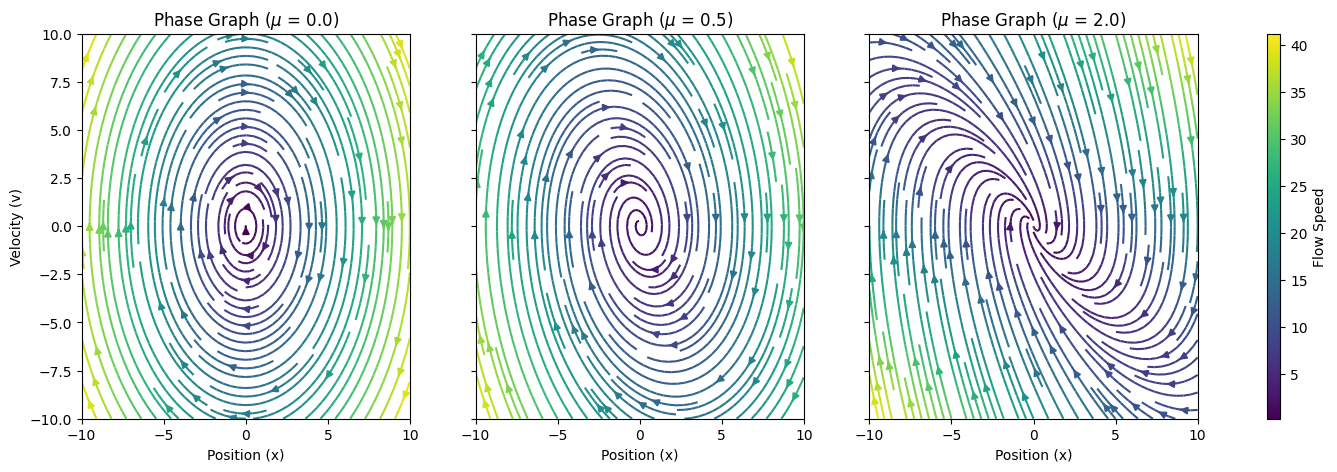

In [121]:
mu_values = [0.0, 0.5, 2.0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, mu in zip(axes, mu_values):
    v_dot = -(k / m) * X - (mu / m) * V
    speed = np.sqrt(x_dot**2 + v_dot**2)

    strm = ax.streamplot(
        x, v, x_dot, v_dot,
        color=speed,
        cmap="viridis",
        linewidth=1.5,
        density=1.5
    )

    ax.set_title(r"Phase Graph ($\mu$ = " + f"{mu})")
    ax.set_xlabel("Position (x)")

axes[0].set_ylabel("Velocity (v)")
fig.colorbar(strm.lines, ax=axes.tolist(), label="Flow Speed", aspect=30)

plt.show()

# Euler

## Normal Way

In [202]:
dt = .0001
steps = 1000000

In [189]:
init_state = np.random.random(2)

A = np.array([[0, 1], [-k / m, -mu / m]])

In [190]:
state = init_state

for i in range(steps):
    state_dot = A @ state
    state = state + state_dot * dt

print(state)

[-1.32130413e-07 -2.36679419e-07]


In [191]:
state = solve_ivp(lambda t, state: A @ state, (0, steps * dt), init_state)

print(state.y[:, -1])

[-3.98474282e-06  3.61787089e-06]


## Try other matrix mult methods but without friction

Trying without friction cause don't wanna worry about numerically instability as we go to 0

In [228]:
init_state = np.random.random(2)

A = np.array([[0, 1], [-k / m, 0]])

In [229]:
state = init_state

for i in range(steps):
    state_dot = A @ state
    state = state + state_dot * dt

print(state)

[ 0.26748911 -0.84049646]


$\text{state}_n = A \cdot \text{state}_{n-1}$
$\text{state}_{n+1} = A \cdot \text{state}_{n} = A \cdot A \cdot \text{state}_{n-1}$
so
$\text{state}_n = A^n \cdot \text{state}_{0}$

In [230]:
M = np.eye(2) + A * dt # If we take out state_(n-1) then we get identity + the rest of this. So we can just do matrix power of this like what I was showing above

state = np.linalg.matrix_power(M, steps) @ init_state

print(state)

[ 0.26748911 -0.84049646]


Diag this tbh
$V D^n V^{-1} x_0$

In [236]:
eigenvalues, V = np.linalg.eig(M)
V_inv = np.linalg.inv(V)

diagonal_state = V_inv @ init_state # Into diag space

final_diagonal_state = (eigenvalues ** steps) * diagonal_state

state = V @ final_diagonal_state

print(state)

[ 0.26748911+0.j -0.84049646+0.j]


In [232]:
t = steps * dt

state_transition_matrix = expm(A * t)

final_state = state_transition_matrix @ init_state

print(state)

[ 0.26748911+0.j -0.84049646+0.j]


## Diff t vals

In [219]:
time = 10
dt_vals = [0.01, 0.001, 0.0001, 0.00001, 0.000001, 0.00000001]

for dt in dt_vals:
    steps = int(time / dt)
    
    M = np.eye(2) + A * dt
    state = np.linalg.matrix_power(M, steps) @ init_state
    print(f"State at dt={dt}: {state}")

print(state)

State at dt=0.01: [ 0.24279985 -1.07923334]
State at dt=0.001: [ 0.22125356 -0.98664731]
State at dt=0.0001: [ 0.21926476 -0.97781022]
State at dt=1e-05: [ 0.21907721 -0.97692624]
State at dt=1e-06: [ 0.21904773 -0.9768427 ]
State at dt=1e-08: [ 0.21904556 -0.97683302]
[ 0.21904556 -0.97683302]


# Van Der Pol

In [ ]:
m = 1.0
k = 2.0
mu = 0.3

# 